In [1]:
from pathlib import Path

import numpy as np
from dataeval.data import ClassFilter, Indices, Limit, Shuffle, View
from datamaite import load_ic
from maite_datasets.image_classification import MilitaryVehicles

from dataeval_flow.preprocessing import PreprocessingStep

data_root = Path("./data")
MilitaryVehicles(root=data_root, image_set="base", download=True)
MilitaryVehicles(root=data_root, image_set="train", as_datamaite=True)

vehicles = load_ic(data_root / "militaryvehicles_datamaite_train" / "train", dataset_format="huggingface_vision")
index2label = vehicles.metadata.get("index2label", {})

HELD_OUT_NAMES = {"30N6E", "Iskander", "Pantsir-S1", "Rs-24"}
held_out = {i for i, name in index2label.items() if name in HELD_OUT_NAMES}
known_classes = [i for i in sorted(index2label) if i not in held_out]

# Both pools are constructed using View operations.
# You build them in Python here because the classification model trains on the
# labeled pool directly before pipeline execution.
#
# Labeled pool: The twenty known classes only.
labeled_dataset = View(vehicles, [ClassFilter(known_classes), Shuffle(seed=42), Limit(4000)])
labeled_indices = labeled_dataset.resolve_indices()

# Unlabeled pool: The remaining frames, containing Air Defense systems and leftover known types.
pool_dataset = View(vehicles, [Indices(labeled_indices, exclude=True), Shuffle(seed=7), Limit(1500)])

pool_labels = np.array([int(np.argmax(pool_dataset[i][1])) for i in range(len(pool_dataset))])
n_novel = int(np.isin(pool_labels, sorted(held_out)).sum())
print(f"Held out (Air Defense): {sorted(index2label[i] for i in held_out)}")
print(f"Labeled pool:   {len(labeled_dataset)} frames, {len(known_classes)} types")
print(
    f"Unlabeled pool: {len(pool_dataset)} frames, {n_novel} of them Air Defense "
    f"({n_novel / len(pool_dataset) * 100:.0f}%)"
)

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Held out (Air Defense): ['30N6E', 'Iskander', 'Pantsir-S1', 'Rs-24']
Labeled pool:   4000 frames, 20 types
Unlabeled pool: 1500 frames, 377 of them Air Defense (25%)


In [2]:
from collections.abc import Mapping
from typing import Any

import numpy as np
from numpy.typing import NDArray
from PIL import Image, ImageFilter


class CorruptedTestDataset:
    """Wraps a MAITE dataset and injects synthetic corruptions into indices 900-999.

    Labels are left untouched throughout, so ground truth stays available for
    verification even though the pixel content at those indices is corrupted.
    """

    _DUPLICATE_OFFSET = 700  # maps index i in [900, 920) to source index i - 700

    def __init__(self, dataset: Any) -> None:
        self._dataset = dataset

    def __len__(self) -> int:
        return len(self._dataset)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        if 900 <= index < 920:
            image, _, _ = self._dataset[index - self._DUPLICATE_OFFSET]
            _, target, metadata = self._dataset[index]
            return np.array(image, copy=True), target, metadata

        image, target, metadata = self._dataset[index]

        if 920 <= index < 940:
            image = self._blur(image)
        elif 940 <= index < 960:
            image = self._add_noise(image, seed=index)
        elif 960 <= index < 980:
            image = self._adjust_exposure(image, 100)
        elif 980 <= index < 1000:
            image = self._adjust_exposure(image, -200, halve=True)

        return image, target, metadata

    @staticmethod
    def _blur(image: NDArray[Any]) -> NDArray[Any]:
        hwc = np.transpose(image, (1, 2, 0))  # CHW -> HWC
        blurred = Image.fromarray(hwc, mode="RGB").filter(ImageFilter.GaussianBlur(radius=3))
        return np.transpose(np.array(blurred, dtype=image.dtype), (2, 0, 1))  # back to CHW

    @staticmethod
    def _add_noise(image: NDArray[Any], *, seed: int) -> NDArray[Any]:
        arr = image.astype(np.int16)
        noise = np.random.default_rng(seed).integers(-80, 80, arr.shape, dtype=np.int16)
        return np.clip(arr + noise, 0, 255).astype(image.dtype)

    @staticmethod
    def _adjust_exposure(image: NDArray[Any], delta: int, *, halve: bool = False) -> NDArray[Any]:
        arr = np.clip(image.astype(np.int16) + delta, 0, 255)
        if halve:
            arr = arr // 2
        return arr.astype(image.dtype)


test_dataset = CorruptedTestDataset(pool_dataset)

print(
    "Test data corruption wrapper ready: 20 exact duplicates (900-919), "
    "20 blurred (920-939), 20 noisy (940-959), "
    "20 bright (960-979), 20 dark (980-999)"
)

Test data corruption wrapper ready: 20 exact duplicates (900-919), 20 blurred (920-939), 20 noisy (940-959), 20 bright (960-979), 20 dark (980-999)


In [3]:
import random

import torch
import torch.nn as nn
import torch.nn.functional as F  # noqa: N812
import torchvision

random.seed(42)
torch.manual_seed(42)


class VehicleNet(nn.Module):
    """A frozen pretrained trunk, a learned embedding, and a head over known classes.

    ``embed`` bundles Linear + ReLU so a forward hook captures the activated output:
    the representation the classifier was trained on.
    """

    def __init__(self, num_classes: int) -> None:
        super().__init__()
        trunk = torchvision.models.resnet18(weights="IMAGENET1K_V1")
        trunk.fc = nn.Identity()
        self.trunk = trunk
        self.embed = nn.Sequential(nn.Linear(512, 128), nn.ReLU())
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.embed(self.trunk(x)))


model = VehicleNet(len(known_classes))
for parameter in model.trunk.parameters():
    parameter.requires_grad = False
model.trunk.eval()

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def _trunk_features(dataset: Any) -> tuple[torch.Tensor, list[int]]:
    """Run the frozen trunk once over a dataset to generate training features for the head."""
    out: list[torch.Tensor] = []
    labels: list[int] = []
    with torch.no_grad():
        for start in range(0, len(dataset), 64):
            batch = []
            for i in range(start, min(start + 64, len(dataset))):
                image, target, _ = dataset[i]
                labels.append(int(np.argmax(target)))
                img = torch.tensor(np.asarray(image), dtype=torch.float32) / 255.0
                img = F.interpolate(img.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False)
                batch.append((img.squeeze(0) - _MEAN) / _STD)
            out.append(model.trunk(torch.stack(batch)))
    return torch.cat(out), labels

In [4]:
_remap = {c: k for k, c in enumerate(known_classes)}
features, labeled_labels = _trunk_features(labeled_dataset)
targets = torch.tensor([_remap[c] for c in labeled_labels], dtype=torch.long)

head = nn.Sequential(model.embed, model.classifier)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
for _epoch in range(40):
    optimizer.zero_grad()
    loss = F.cross_entropy(head(features), targets)
    loss.backward()
    optimizer.step()
model.eval()

accuracy = (head(features).argmax(1) == targets).float().mean().item()
print(f"Head trained: loss={loss.item():.3f}, accuracy on the labeled pool={accuracy * 100:.1f}%")

Head trained: loss=1.677, accuracy on the labeled pool=50.2%


In [5]:
model_path = Path("./models/vehiclenet.pt")
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model, str(model_path))
print(f"Model saved to {model_path}")

Model saved to models/vehiclenet.pt


In [6]:
from dataeval_flow.config import (
    DatasetProtocolConfig,
    PipelineConfig,
    PreprocessorConfig,
    SourceConfig,
)
from dataeval_flow.config.schemas import (
    DataPrioritizationTaskConfig,
    DataPrioritizationWorkflowConfig,
    TorchExtractorConfig,
)

ref_dataset = labeled_dataset

from dataeval_flow.workflows.prioritization.params import CleaningConfig

workflow = DataPrioritizationWorkflowConfig(
    name="vehicles_prioritize",
    method="knn",
    k=5,
    order="hard_first",
    policy="difficulty",
    mode="preparatory",
    cleaning=CleaningConfig(
        outlier_method="adaptive",
        outlier_flags=["dimension", "pixel", "visual"],
        outlier_threshold=3.0,  # lower than default 3.5 to catch subtler corruptions
        duplicate_exact_only=True,
    ),
)

task = DataPrioritizationTaskConfig(
    name="prioritize_pool",
    workflow="vehicles_prioritize",
    sources=["ref_src", "test_src"],
    extractor="cnn_extractor",
)

In [7]:
config = PipelineConfig(
    datasets=[
        DatasetProtocolConfig(name="ref_ds", dataset=ref_dataset),
        DatasetProtocolConfig(name="test_ds", dataset=test_dataset),
    ],
    preprocessors=[
        PreprocessorConfig(
            name="imagenet",
            steps=[
                PreprocessingStep(step="Resize", params={"size": [224, 224], "antialias": True}),
                PreprocessingStep(step="ToDtype", params={"dtype": "float32", "scale": True}),
                PreprocessingStep(
                    step="Normalize",
                    params={"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
                ),
            ],
        ),
    ],
    sources=[
        SourceConfig(name="ref_src", dataset="ref_ds"),
        SourceConfig(name="test_src", dataset="test_ds"),
    ],
    extractors=[
        TorchExtractorConfig(
            name="cnn_extractor",
            model_path=str(model_path),
            layer_name="embed",
            device="cpu",
            preprocessor="imagenet",
            batch_size=32,
        ),
    ],
    workflows=[workflow],
    tasks=[task],
)

In [8]:
from dataeval_flow.workflow import run_task

result = run_task(task, config, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/dataeval/types/_output.py:270: FutureWarning: The default value of hash_radius will change from 0 in a future major release, so that Duplicates finds the perceptual near-duplicates it documents rather than only bit-identical ones (5 of 64 bits is the expected value). Pass hash_radius explicitly to pin the current behavior and silence this warning.
  result = fn(*args, **kwargs)


In [9]:
if not result.success:
    print(f"Workflow failed: {result.errors}")
assert result.success

In [10]:
print(result.report())


  PRIORITIZATION COMPLETE. 1263 ITEMS RANKED VIA KNN.
  Timestamp:    2026-09-19T01:41:39.319426+00:00
  Duration:     20.86s
  Source:       ref_src (ref_ds)
                test_src (test_ds)
  Model:        cnn_extractor (torch)
  Preprocessor: imagenet
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Pruning ............................................ 852 items (15.5%)  [..]
  Prioritization: test_src .................................. 1263 items  [..]

  Health: All checks passed [ok]

  PRUNING                                                      852 items (15.5%)
  Pruning removed 852/5500 items (15.5%): 814 outliers, 47 duplicates

  total_combined      5500
  outliers_flagged    814
  duplicates_flagged  47
  total_removed       852
  removed_pct         15.5%

  PRIORITIZATION: TEST_SRC                                            1263 items
  test_src: 1263 items prioritized via knn (hard_first, difficulty)

  source    

In [11]:
raw = result.data.raw
meta = result.metadata

print(f"Pruning enabled: {meta.cleaning_enabled}")
print(f"Items removed by pruning: {meta.items_removed_by_cleaning}")

if raw.cleaning_summary is not None:
    cs = raw.cleaning_summary
    print(f"  Outliers flagged:    {cs['outliers_flagged']}")
    print(f"  Duplicates flagged:  {cs['duplicates_flagged']}")
    print(f"  Total removed:       {cs['total_removed']}")

Pruning enabled: True
Items removed by pruning: 852
  Outliers flagged:    814
  Duplicates flagged:  47
  Total removed:       852


In [12]:
# Which pool indices were pruned?
all_test_indices = set(range(len(test_dataset)))
clean_test_indices = set(meta.per_source_clean_indices.get("test_src", []))
pruned_indices = sorted(all_test_indices - clean_test_indices)

print(f"Pool frames: {len(all_test_indices)} total, {len(clean_test_indices)} clean, {len(pruned_indices)} pruned")

# Check overlap with known corrupted ranges
corrupted_ranges = {
    "duplicates (900-919)": set(range(900, 920)),
    "blurred (920-939)": set(range(920, 940)),
    "noisy (940-959)": set(range(940, 960)),
    "bright (960-979)": set(range(960, 980)),
    "dark (980-999)": set(range(980, 1000)),
}
pruned_set = set(pruned_indices)
print("\nOverlap with injected corruptions:")
for name, indices in corrupted_ranges.items():
    overlap = pruned_set & indices
    print(f"  {name}: {len(overlap)}/{len(indices)} pruned")

planted = set(range(900, 1000)) | set(range(200, 220))
other_pruned = pruned_set - planted
if other_pruned:
    print(f"  Other frames pruned: {len(other_pruned)} of {len(all_test_indices) - len(planted)}")

Pool frames: 1500 total, 1263 clean, 237 pruned

Overlap with injected corruptions:
  duplicates (900-919): 20/20 pruned
  blurred (920-939): 2/20 pruned
  noisy (940-959): 7/20 pruned
  bright (960-979): 5/20 pruned
  dark (980-999): 20/20 pruned
  Other frames pruned: 181 of 1380


In [13]:
prioritized = result.data.raw.prioritizations[0]
top_indices = prioritized["prioritized_indices"]

# `pool_labels` was read straight off the view; the corruption wrapper alters pixels only,
# so a frame's ground-truth label is the same whether or not it was corrupted.
is_novel = np.isin(pool_labels[top_indices], sorted(held_out))
baseline_pct = 100.0 * is_novel.mean()

print(f"Baseline (share of the ranked set): {baseline_pct:.0f}% Air Defense\n")
print(f"{'Budget':>8}  {'Air Defense':>12}  {'vs random':>10}")
for n in (50, 100, 200, 500):
    pct = 100.0 * is_novel[:n].mean()
    print(f"{n:>8}  {pct:>11.0f}%  {pct / baseline_pct:>9.2f}x")

Baseline (share of the ranked set): 26% Air Defense

  Budget   Air Defense   vs random
      50           44%       1.71x
     100           45%       1.75x
     200           41%       1.59x
     500           36%       1.38x


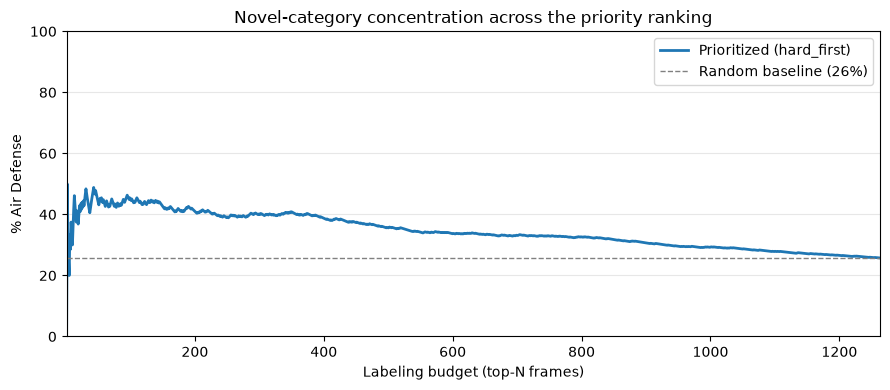

In [14]:
cumulative = np.cumsum(is_novel)
n_items = np.arange(1, len(cumulative) + 1)
novel_pct = 100.0 * cumulative / n_items

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(n_items, novel_pct, linewidth=2, label="Prioritized (hard_first)")
    ax.axhline(baseline_pct, color="gray", linestyle="--", linewidth=1, label=f"Random baseline ({baseline_pct:.0f}%)")
    ax.set_xlabel("Labeling budget (top-N frames)")
    ax.set_ylabel("% Air Defense")
    ax.set_title("Novel-category concentration across the priority ranking")
    ax.set_xlim(1, len(cumulative))
    ax.set_ylim(0, max(100, novel_pct[:50].max() * 1.2))
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    for n in (50, 100, 200, 500, len(cumulative)):
        print(f"Top {n:4d}: {novel_pct[n - 1]:.0f}% novel")

In [15]:
def _normalized(idx: int) -> torch.Tensor:
    """One pool frame, in the shape the model expects."""
    img = torch.tensor(np.asarray(test_dataset[idx][0]), dtype=torch.float32) / 255.0
    img = F.interpolate(img.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False)
    return (img.squeeze(0) - _MEAN) / _STD


# Batched, because the whole pool at 224x224 does not fit in memory at once.
_probs = []
with torch.no_grad():
    for start in range(0, len(top_indices), 32):
        batch = torch.stack([_normalized(i) for i in top_indices[start : start + 32]])
        _probs.append(torch.softmax(model(batch), dim=1))
probabilities = torch.cat(_probs).numpy()

entropy = -(probabilities * np.log(probabilities + 1e-9)).sum(axis=1)
by_entropy = np.argsort(-entropy)
novel_by_entropy = is_novel[by_entropy]

print(f"{'Budget':>8}  {'hard_first':>11}  {'by entropy':>11}  {'baseline':>9}")
for n in (50, 100, 200, 500):
    print(
        f"{n:>8}  {100.0 * is_novel[:n].mean():>10.0f}%  "
        f"{100.0 * novel_by_entropy[:n].mean():>10.0f}%  {baseline_pct:>8.0f}%"
    )

  Budget   hard_first   by entropy   baseline
      50          44%          20%        26%
     100          45%          24%        26%
     200          41%          23%        26%
     500          36%          21%        26%


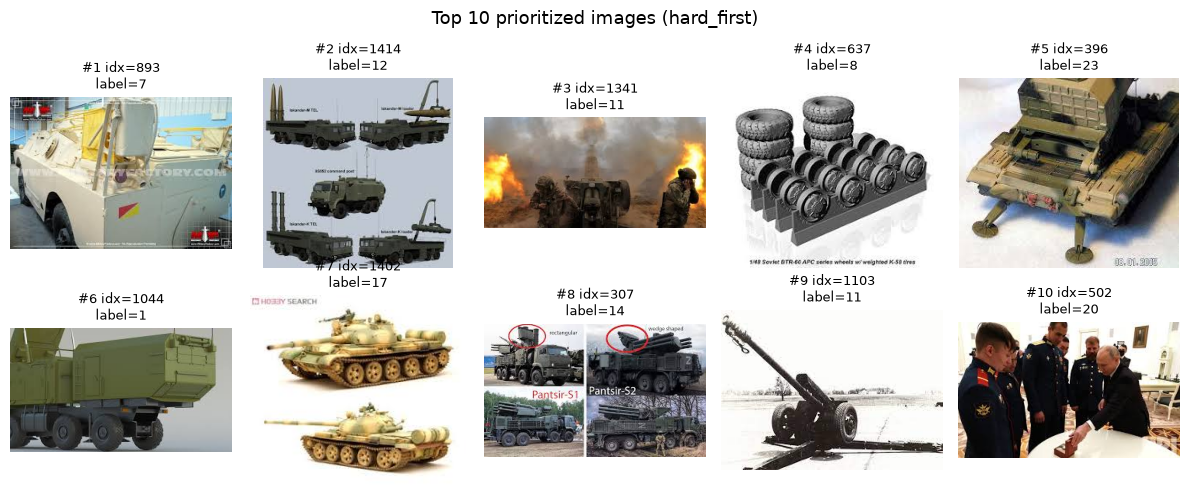

In [16]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        idx = top_indices[i]
        img, target, _ = test_dataset[idx]
        img_arr = np.transpose(np.asarray(img), (1, 2, 0))  # CHW -> HWC
        label = int(np.argmax(target))
        ax.imshow(img_arr)
        ax.set_title(f"#{i + 1} idx={idx}\nlabel={label}", fontsize=9)
        ax.axis("off")
    fig.suptitle("Top 10 prioritized images (hard_first)", fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install matplotlib to visualize: pip install matplotlib")